# Import libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the cleaned dataset

In [4]:

df = pd.read_csv("C:\\Users\\AKSHITHA\\Downloads\\adult_income.csv")

print("Dataset shape:", df.shape)

Dataset shape: (48841, 20)


# Basic inspection

In [5]:
print("Rows and Columns:", df.shape)

print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Rows and Columns: (48841, 20)

Column Names:
['age', 'workclass', 'fnlwgt', 'education', 'education_num', 'marital_status', 'occupation', 'relationship', 'race', 'sex', 'capital_gain', 'capital_loss', 'hours_per_week', 'native_country', 'income', 'source_split', 'high_income', 'age_group', 'hours_group', 'net_capital']

Data Types:
age               int64
workclass           str
fnlwgt            int64
education           str
education_num     int64
marital_status      str
occupation          str
relationship        str
race                str
sex                 str
capital_gain      int64
capital_loss      int64
hours_per_week    int64
native_country      str
income              str
source_split        str
high_income       int64
age_group           str
hours_group         str
net_capital       int64
dtype: object

Missing Values:
age               0
workclass         0
fnlwgt            0
education         0
education_num     0
marital_status    0
occupation        0
relationship   

# 1. Overall Income Distribution

# Income counts

In [6]:
income_counts = df["income"].value_counts()

print(income_counts)

income
<=50K    37154
>50K     11687
Name: count, dtype: int64


# Income distribution chart

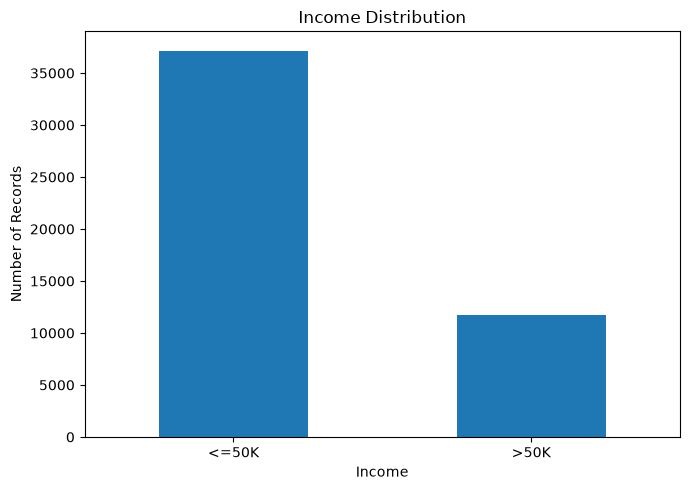

In [7]:
plt.figure(figsize=(7, 5))

income_counts.plot(kind="bar")

plt.title("Income Distribution")
plt.xlabel("Income")
plt.ylabel("Number of Records")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 2. Proportion Above $50K

In [8]:
income_percentage = df["high_income"].value_counts(normalize=True) * 100

print("Income distribution (%):")
print(income_percentage)

Income distribution (%):
high_income
0    76.071334
1    23.928666
Name: proportion, dtype: float64


In [10]:
above_50k_rate = df["high_income"].mean() * 100

print(f"Percentage of records with income above $50K: {above_50k_rate:.2f}%")

Percentage of records with income above $50K: 23.93%


# 3. Education vs Income

In [11]:
education_income = (
    df.groupby("education")["high_income"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(education_income)

education
Prof-school     73.980815
Doctorate       72.558923
Masters         54.911554
Bachelors       41.283489
Assoc-acdm      25.796377
Assoc-voc       25.327511
Some-college    18.964883
HS-grad         15.857831
12th             7.305936
7th-8th          6.492147
10th             6.263499
9th              5.423280
5th-6th          5.304519
11th             5.080066
1st-4th          3.238866
Preschool        1.204819
Name: high_income, dtype: float64


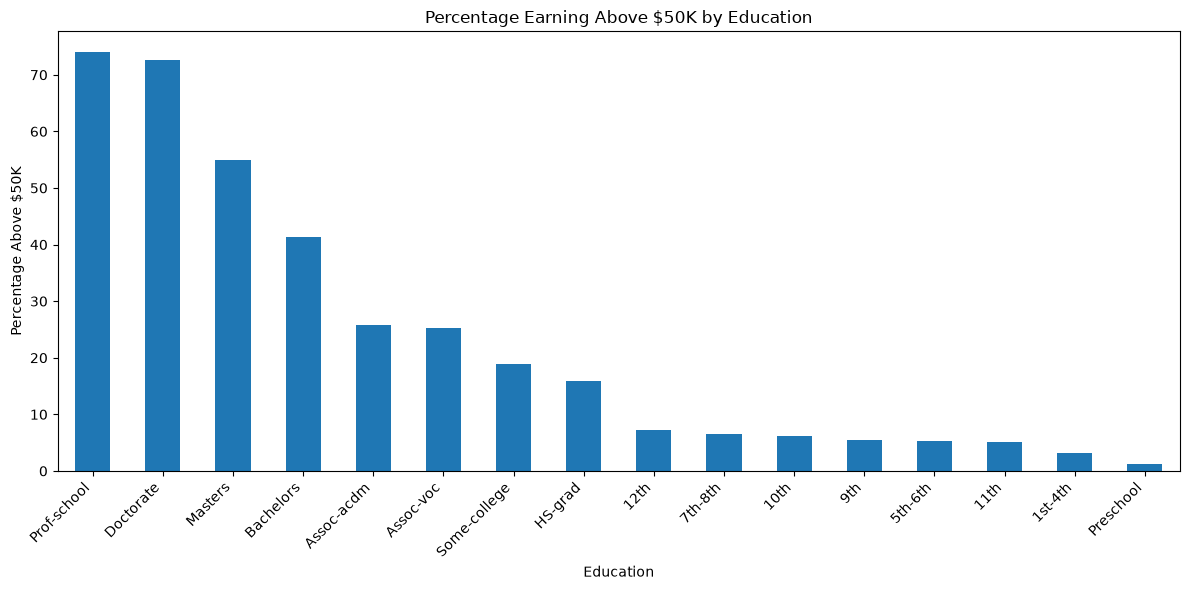

In [10]:
plt.figure(figsize=(12, 6))

education_income.plot(kind="bar")

plt.title("Percentage Earning Above $50K by Education")
plt.xlabel("Education")
plt.ylabel("Percentage Above $50K")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 4. Occupation vs Income

In [12]:
occupation_income = (
    df.groupby("occupation")["high_income"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(occupation_income)

occupation
Exec-managerial      47.781794
Prof-specialty       45.106935
Armed-Forces         33.333333
Protective-serv      31.332655
Tech-support         29.045643
Sales                26.798692
Craft-repair         22.627618
Transport-moving     20.424628
Adm-clerical         13.687400
Machine-op-inspct    12.313803
Farming-fishing      11.610738
Unknown               9.433962
Handlers-cleaners     6.660232
Other-service         4.143815
Priv-house-serv       1.239669
Name: high_income, dtype: float64


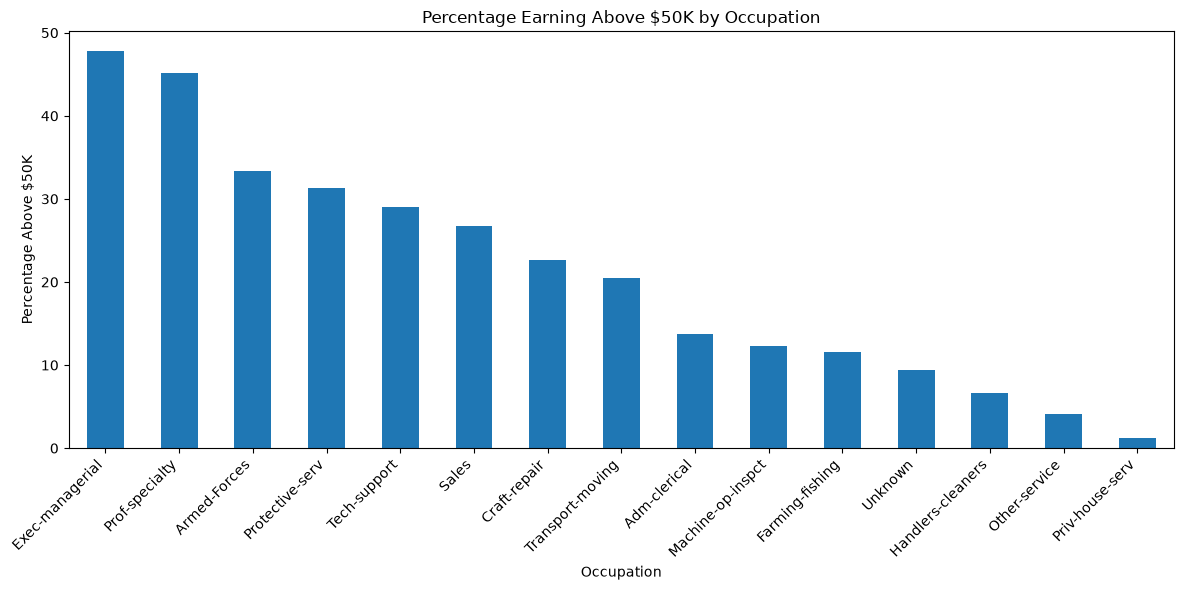

In [13]:
plt.figure(figsize=(12, 6))

occupation_income.plot(kind="bar")

plt.title("Percentage Earning Above $50K by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Percentage Above $50K")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 5. Age Group vs Income

In [14]:
age_income = (
    df.groupby("age_group", observed=False)["high_income"]
    .mean()
    .mul(100)
)

print(age_income)

age_group
17-24     1.102941
25-34    16.817748
35-44    33.289592
45-54    39.391175
55-64    32.162275
65+      20.459990
Name: high_income, dtype: float64


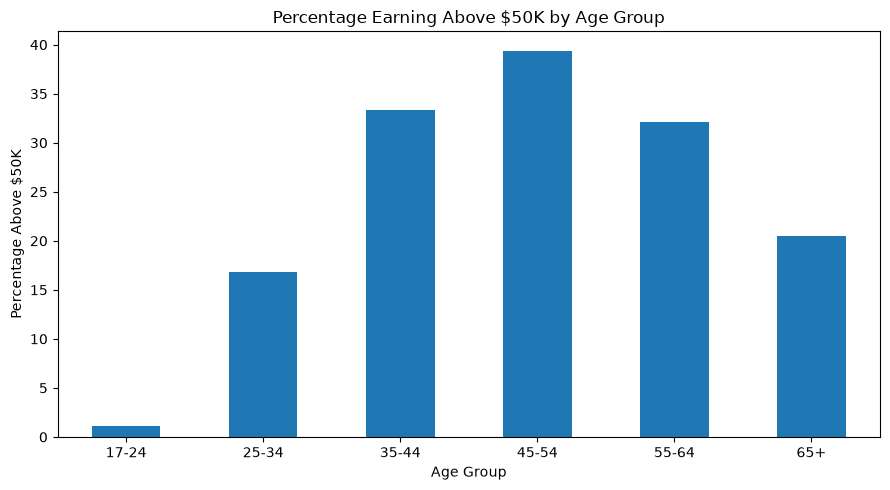

In [15]:
plt.figure(figsize=(9, 5))

age_income.plot(kind="bar")

plt.title("Percentage Earning Above $50K by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Percentage Above $50K")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 6. Workclass vs Income

 

In [15]:
workclass_income = (
    df.groupby("workclass")["high_income"]
    .mean()
    .mul(100)
    .sort_values(ascending=False)
)

print(workclass_income)

workclass
Self-emp-inc        55.339233
Federal-gov         39.175978
Local-gov           29.559949
Self-emp-not-inc    27.887105
State-gov           26.754165
Private             21.787347
Without-pay          9.523810
Unknown              9.467667
Never-worked         0.000000
Name: high_income, dtype: float64


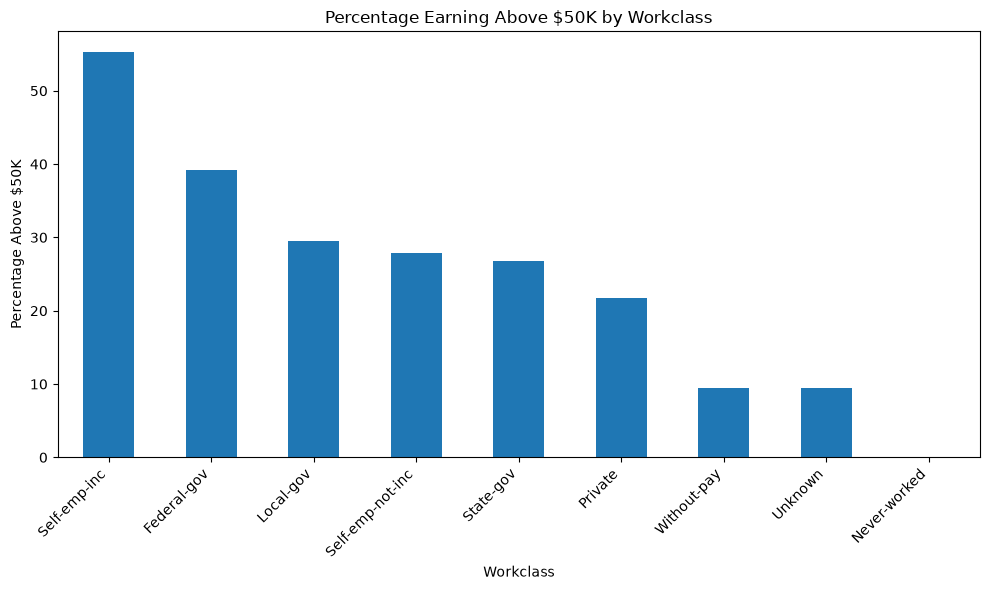

In [17]:
plt.figure(figsize=(10, 6))

workclass_income.plot(kind="bar")

plt.title("Percentage Earning Above $50K by Workclass")
plt.xlabel("Workclass")
plt.ylabel("Percentage Above $50K")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

# 7. Sex vs Income

In [16]:
sex_income = (
    df.groupby("sex")["high_income"]
    .mean()
    .mul(100)
)

print(sex_income)

sex
Female    10.925148
Male      30.377653
Name: high_income, dtype: float64


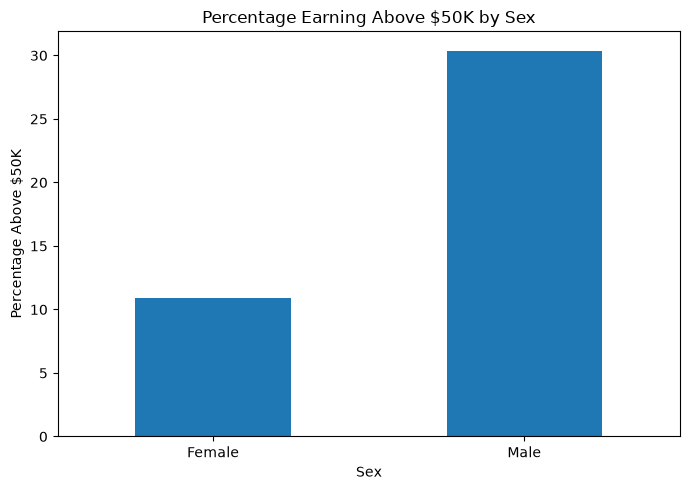

In [19]:
plt.figure(figsize=(7, 5))

sex_income.plot(kind="bar")

plt.title("Percentage Earning Above $50K by Sex")
plt.xlabel("Sex")
plt.ylabel("Percentage Above $50K")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

# 8. Weekly Working Hours

In [17]:
hours_summary = df.groupby("income")["hours_per_week"].describe()

hours_summary

,count,mean,std,min,25%,50%,75%,max
income,,,,,,,,
<=50K,37154.0,38.840017,12.357014,1.0,35.0,40.0,40.0,99.0
>50K,11687.0,45.452896,11.091176,1.0,40.0,40.0,50.0,99.0


# Box plot

<Figure size 800x600 with 0 Axes>

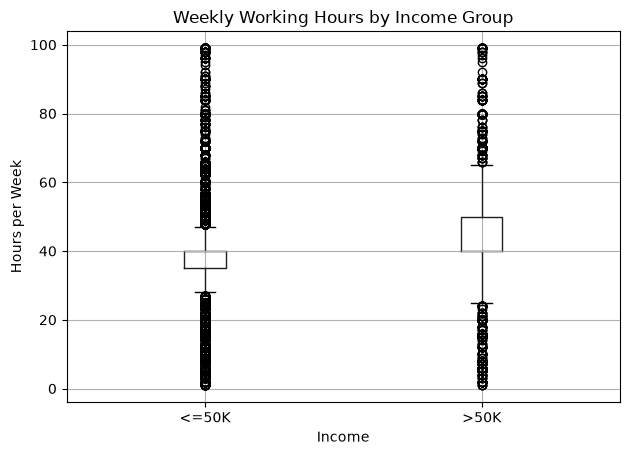

In [18]:
plt.figure(figsize=(8, 6))

df.boxplot(
    column="hours_per_week",
    by="income"
)

plt.title("Weekly Working Hours by Income Group")
plt.suptitle("")
plt.xlabel("Income")
plt.ylabel("Hours per Week")

plt.tight_layout()
plt.show()

# 9. Weekly Hours Distribution

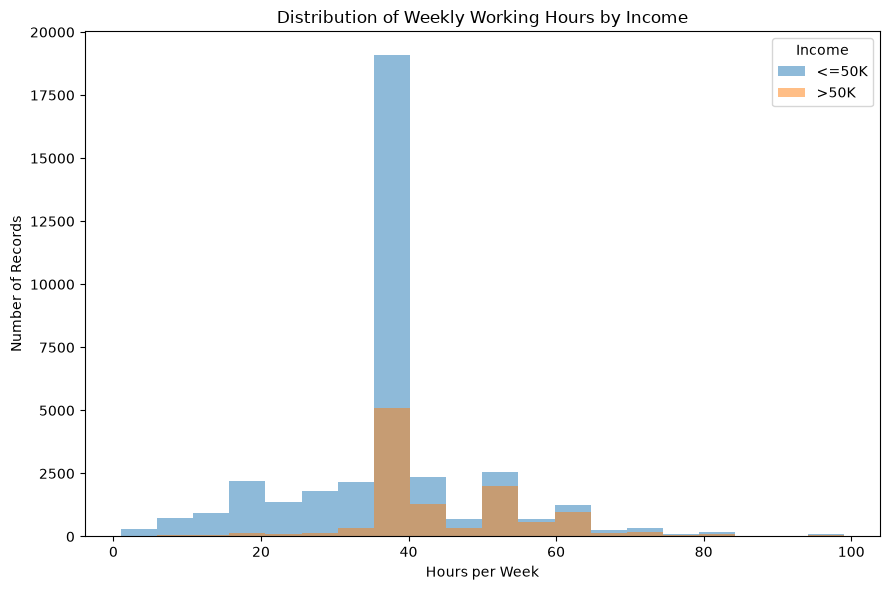

In [19]:
plt.figure(figsize=(9, 6))

for income_group in df["income"].dropna().unique():
    subset = df[df["income"] == income_group]
    plt.hist(
        subset["hours_per_week"],
        bins=20,
        alpha=0.5,
        label=income_group
    )

plt.title("Distribution of Weekly Working Hours by Income")
plt.xlabel("Hours per Week")
plt.ylabel("Number of Records")
plt.legend(title="Income")

plt.tight_layout()
plt.show()

# 10. Capital Gain and Capital Loss

In [20]:
capital_summary = df[
    ["capital_gain", "capital_loss", "net_capital"]
].describe()

capital_summary

,capital_gain,capital_loss,net_capital
count,48841.000000,48841.000000,48841.000000
mean,1079.089720,87.504105,991.585615
std,7452.093748,403.008483,7475.625090
min,0.000000,0.000000,-4356.000000
25%,0.000000,0.000000,0.000000
50%,0.000000,0.000000,0.000000
75%,0.000000,0.000000,0.000000
max,99999.000000,4356.000000,99999.000000


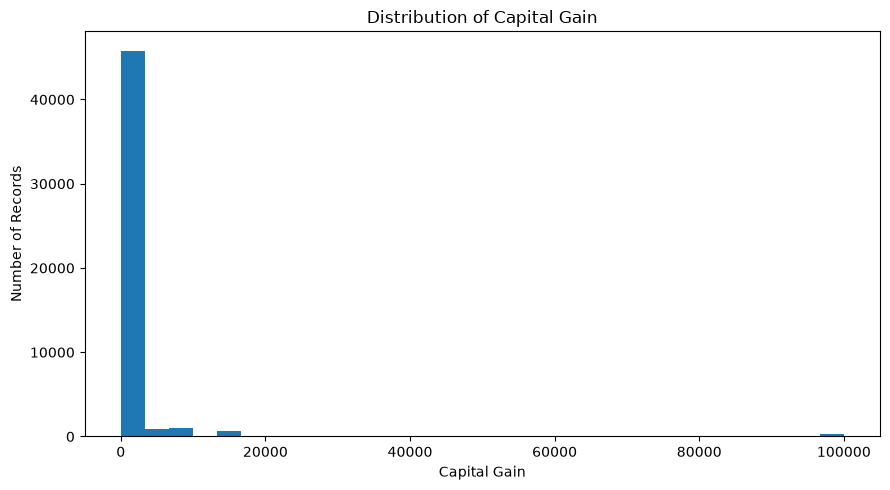

In [24]:
plt.figure(figsize=(9, 5))

plt.hist(df["capital_gain"], bins=30)

plt.title("Distribution of Capital Gain")
plt.xlabel("Capital Gain")
plt.ylabel("Number of Records")

plt.tight_layout()
plt.show()

In [21]:
capital_income = (
    df.groupby("income")["capital_gain"]
    .mean()
)

print(capital_income)

income
<=50K     147.014265
>50K     4042.239497
Name: capital_gain, dtype: float64


# 11. Numeric Relationships

In [22]:
numeric_columns = [
    "age",
    "fnlwgt",
    "education_num",
    "capital_gain",
    "capital_loss",
    "hours_per_week",
    "net_capital"
]

correlation = df[numeric_columns].corr()

correlation

,age,fnlwgt,education_num,capital_gain,capital_loss,hours_per_week,net_capital
age,1.000000,-0.076622,0.030917,0.077227,0.056940,0.071558,0.073914
fnlwgt,-0.076622,1.000000,-0.038753,-0.003705,-0.004365,-0.013518,-0.003458
education_num,0.030917,-0.038753,1.000000,0.125145,0.080968,0.143690,0.120386
capital_gain,0.077227,-0.003705,0.125145,1.000000,-0.031441,0.082157,0.998547
capital_loss,0.056940,-0.004365,0.080968,-0.031441,1.000000,0.054467,-0.085252
hours_per_week,0.071558,-0.013518,0.143690,0.082157,0.054467,1.000000,0.078962
net_capital,0.073914,-0.003458,0.120386,0.998547,-0.085252,0.078962,1.000000


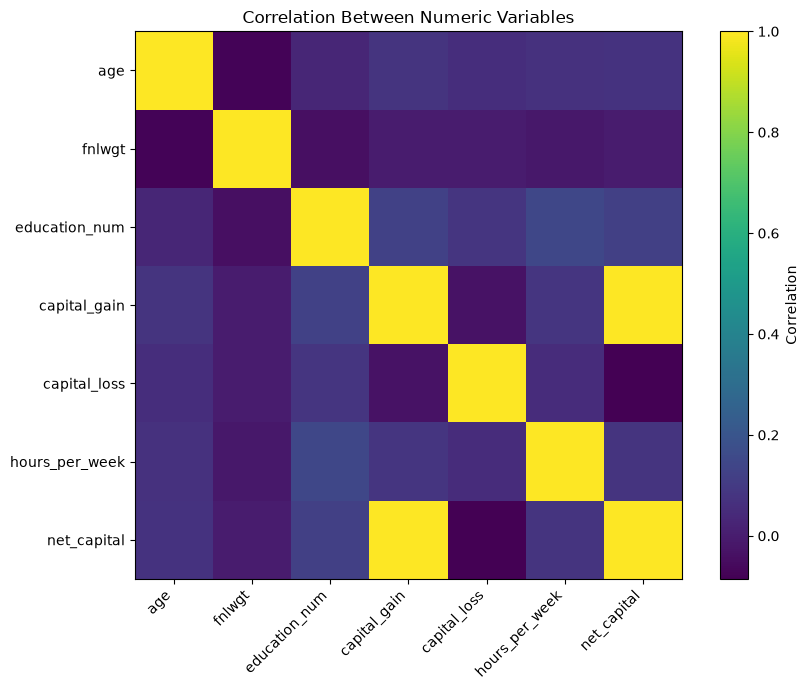

In [23]:
plt.figure(figsize=(9, 7))

plt.imshow(correlation)

plt.xticks(
    range(len(numeric_columns)),
    numeric_columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    range(len(numeric_columns)),
    numeric_columns
)

plt.colorbar(label="Correlation")

plt.title("Correlation Between Numeric Variables")

plt.tight_layout()
plt.show()